In [1]:
import wave

filename = "files/Hello-out.wav"

In [2]:
from struct import unpack

def unpack_wavefile(filename):
    w = wave.Wave_read(filename)

    data = []
    for i in range(w.getnframes()):
        data.append(
            unpack(
                'h',    # format
                w.readframes(1)  # buffer
            )[0]
        )
    return data

def scale_data(d):
    scale = max(max(d), abs(min(d))) * 1.0
    return [x/scale for x in d]

def get_differences(d):
    return [d[i] - d[i-1] for i in range(1, len(d))]

data = unpack_wavefile(filename)
# data = scale_data(data)
# data = get_differences(data)

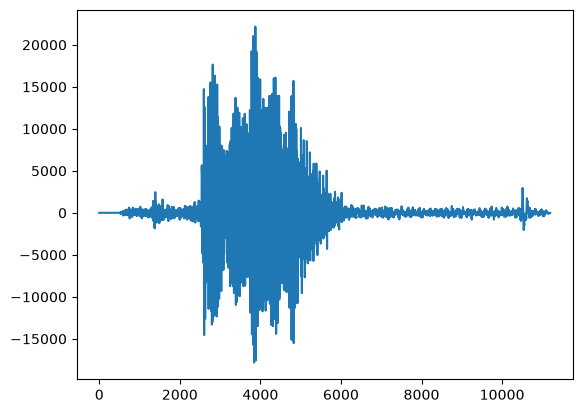

In [3]:
import matplotlib.pyplot as plt

plt.plot(data)

In [4]:
max(data), min(data)

(22168, -17823)

In [5]:
-2**15 + 1, 2**15

(-32767, 32768)

In [6]:
import numpy as np

data = np.array(data)

In [7]:
data_u = data + 2**15

data_8 = 255 * data_u / 2**16

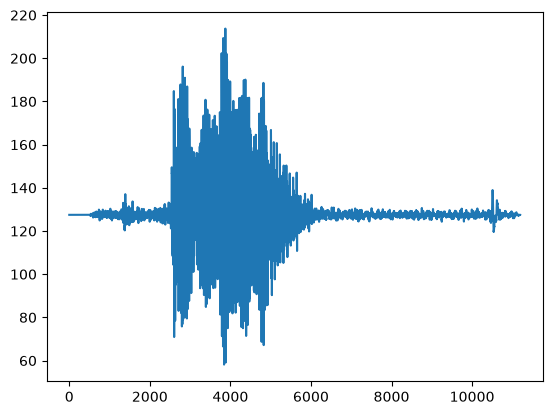

In [8]:
plt.plot(data_8)

In [9]:
data_8 = data_8.astype(int)

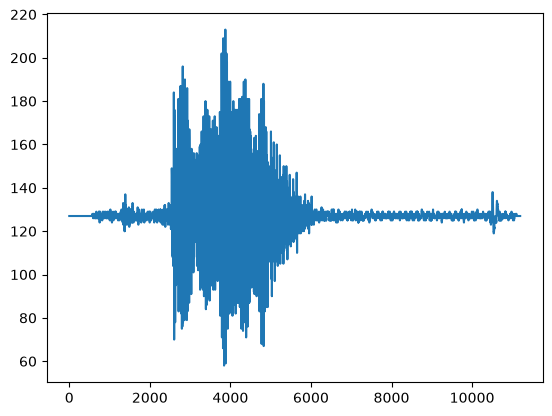

In [10]:
plt.plot(data_8)

In [11]:
def createHeader(filename, data_8bit):
    outfile = open("../PCM_" + filename + ".h", "w")
    outfile.write('const uint8_t PCM_{}[] PROGMEM = {{\n'.format(filename))
    for byte in data_8bit:
        outfile.write('  {:d},\n'.format(byte))
    outfile.write('};\n')
    outfile.close()

createHeader('hello', data_8)


In [12]:
len(data_8)

11195